In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)
X = np.sort(np.random.rand(30, 1) * 6)
# Flatten y to 1D using .ravel() so coefficients are 1D arrays
y = (0.5 * X**2 + X + 2 + np.random.rand(30, 1) * 1.5).ravel()

# Degree 10 polynomial
poly_features = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly_features.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Feature scaling important for regularization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3 models comparison
ridge = Ridge(alpha=1)
lasso = Lasso(alpha=0.1, max_iter=10_000)
lr = LinearRegression()

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)

print("=" * 60)
print(f"{'Feature':<10} {'Linear':>12} {'Ridge':>12} {'Lasso':>12}")
print("=" * 60)

for i in range(min(11, len(lr.coef_))):
    l_coef = lr.coef_[i] if i < len(lr.coef_) else 0
    r_coef = ridge.coef_[i] if i < len(ridge.coef_) else 0
    la_coef = lasso.coef_[i] if i < len(lasso.coef_) else 0
    print(f"theta{i:<9} {l_coef:>12.2f} {r_coef:>12.2f} {la_coef:>12.2f}")

print("=" * 60)

print(f"\nLinear - nolga teng koeff: {np.sum(np.abs(lr.coef_) < 0.01)}")
print(f" Ridge - nolga teng koeff : {np.sum(np.abs(ridge.coef_) < 0.01)}")
print(f" Lasso - nolga teng koeff : {np.sum(np.abs(lasso.coef_) < 0.01)}")

Feature          Linear        Ridge        Lasso
theta0               -14.01         2.97         2.53
theta1               514.39         2.01         4.11
theta2             -5453.77         1.27         0.35
theta3             29793.34         0.73         0.00
theta4            -95825.02         0.37         0.00
theta5            192382.22         0.13         0.00
theta6           -244273.36        -0.02         0.00
theta7            190850.74        -0.11         0.00
theta8            -83808.31        -0.15         0.00
theta9             15840.97        -0.17         0.03

Linear - nolga teng koeff: 0
 Ridge - nolga teng koeff : 0
 Lasso - nolga teng koeff : 6


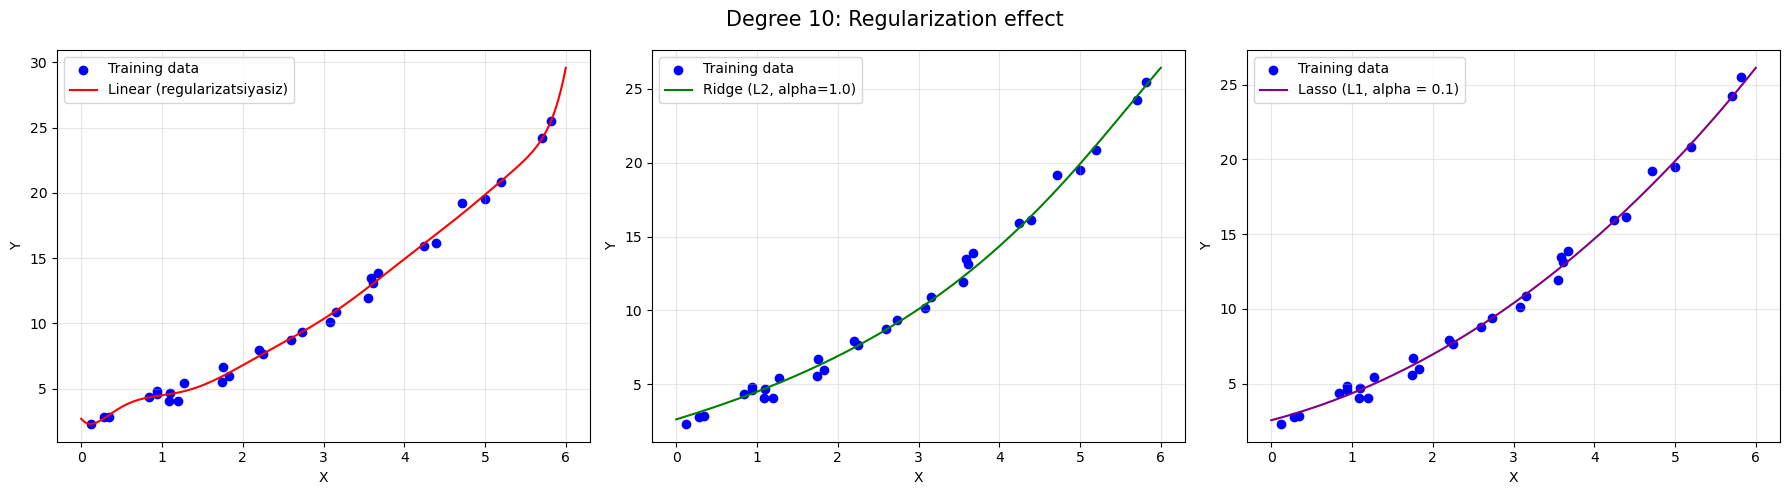

In [3]:
X_plot = np.linspace(0, 6, 200).reshape(-1, 1)
X_plot_poly = poly_features.transform(X_plot)
X_poly_s = scaler.transform(X_plot_poly)

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

models = [
    (lr, "Linear (regularizatsiyasiz)", 'red'),
    (ridge, 'Ridge (L2, alpha=1.0)', 'green'),
    (lasso, 'Lasso (L1, alpha = 0.1)', 'purple')
]

for ax, (model, title, color) in zip(axes, models):
    y_pred_plot = model.predict(X_poly_s)
    ax.scatter(X, y, color="blue", label="Training data")
    ax.plot(X_plot, y_pred_plot, color=color, label=title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Degree 10: Regularization effect", fontsize=15)
plt.tight_layout()
plt.show()


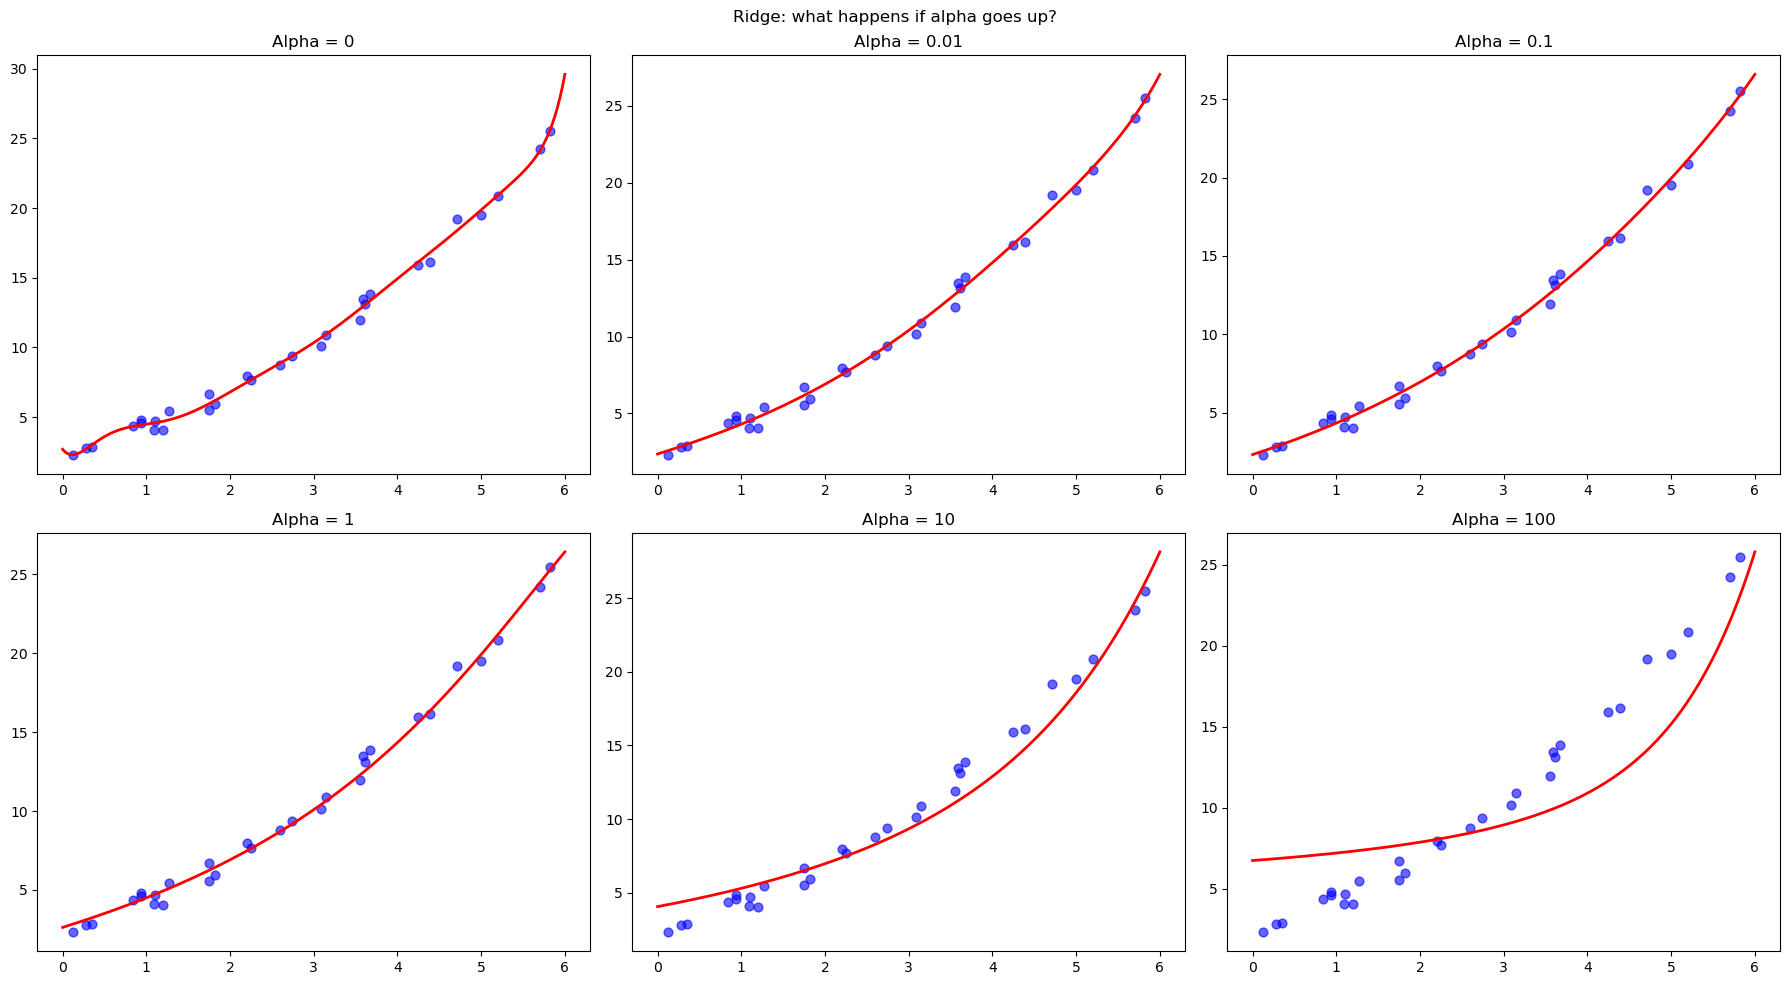

In [4]:
alphas = [0, 0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Create smooth points for drawing the continuous curve
X_plot = np.linspace(0, 6, 200).reshape(-1, 1)
X_plot_poly = poly_features.transform(X_plot)
X_plot_scaled = scaler.transform(X_plot_poly)

for ax, alpha in zip(axes.flatten(), alphas):
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Ridge(alpha=alpha)
        
    model.fit(X_train_scaled, y_train)
    
    # Predict on the smooth curve for this specific model/alpha
    y_pred_plot = model.predict(X_plot_scaled)

    # Plot data points and the unique curve for this alpha
    ax.scatter(X, y, color="blue", s=40, alpha=0.6)
    ax.plot(X_plot, y_pred_plot, "r-", linewidth=2)
    ax.set_title(f"Alpha = {alpha}")

plt.suptitle("Ridge: what happens if alpha goes up?")
plt.tight_layout()
plt.show()


In [5]:
# Lets see Lasso feature selection:

print("Lasso feature selection")
print("Lasso makes some features weights 0, means these features are found to be useless")

for a in [0, 0.01, 0.1, 1, 10, 100]:
  lasso_test = Lasso(alpha=a, max_iter=10_000)
  lasso_test.fit(X_train_scaled, y_train)
  n_zero = np.sum(np.abs(lasso_test.coef_)<0.001)
  n_total = len(lasso_test.coef_)
  print(f"alpha={a} ---> {n_zero}/{n_total} coeff=0, {n_total-n_zero} features left")


Lasso feature selection
Lasso makes some features weights 0, means these features are found to be useless
alpha=0 ---> 0/10 coeff=0, 10 features left
alpha=0.01 ---> 6/10 coeff=0, 4 features left
alpha=0.1 ---> 6/10 coeff=0, 4 features left
alpha=1 ---> 8/10 coeff=0, 2 features left
alpha=10 ---> 10/10 coeff=0, 0 features left
alpha=100 ---> 10/10 coeff=0, 0 features left


c:\Users\OsiyoComputers\anaconda\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\OsiyoComputers\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\OsiyoComputers\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.488e+00, tolerance: 1.198e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.e